In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    GRU,
    Dense,
    Dropout,
    LayerNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.optimizers import Adam


In [2]:
df = pd.read_csv("water_consumption_dataset.csv")

df["Date"] = pd.to_datetime(df["Date"])

df.sort_values("Date", inplace=True)

df.reset_index(drop=True, inplace=True)

target = "Total_Daily_Usage_ML"


In [3]:
df['month_sin'] = np.sin(
    2*np.pi*df['Month']/12
)

df['month_cos'] = np.cos(
    2*np.pi*df['Month']/12
)

df['day_sin'] = np.sin(
    2*np.pi*df['Day_of_Year']/365
)

df['day_cos'] = np.cos(
    2*np.pi*df['Day_of_Year']/365
)


In [4]:
for lag in [1,2,3,4,5,7,14,21,30,60,90,180,365]:
    df[f'lag_{lag}'] = df[target].shift(lag)

# =====================================================
# MOVING AVERAGES
# =====================================================

df['ma_7'] = df[target].rolling(7).mean()

df['ma_30'] = df[target].rolling(30).mean()

# Remove ma_90 (too much smoothing)

# =====================================================
# STANDARD DEVIATION
# =====================================================

df['std_7'] = df[target].rolling(7).std()

df['std_30'] = df[target].rolling(30).std()

# =====================================================
# EXPONENTIAL MOVING AVERAGES
# =====================================================

df['ema_7'] = df[target].ewm(span=7).mean()

df['ema_30'] = df[target].ewm(span=30).mean()

# =====================================================
# TREND FEATURES
# =====================================================

df['diff_1'] = df[target].diff(1)

df['diff_7'] = df[target].diff(7)

# =====================================================
# PERCENT CHANGE FEATURES
# =====================================================

df['pct_change_1'] = df[target].pct_change(1)

df['pct_change_7'] = df[target].pct_change(7)

# =====================================================
# CLEAN
# =====================================================

df.dropna(inplace=True)


In [5]:
features = [

    'Day_of_Week',
    'Month',
    'Year',
    'Day_of_Year',

    'Is_Weekend',
    'Holiday_Flag',

    'Temperature_C',
    'Rainfall_mm',
    'Humidity_pct',
    'Evaporation_Rate_mm',

    'Population',
    'Household_Count',
    'Urbanization_Index',

    'Pump_Status',

    'Reservoir_Level_pct',

    'month_sin',
    'month_cos',

    'day_sin',
    'day_cos',

    'lag_1',
    'lag_2',
    'lag_3',
    'lag_4',
    'lag_5',
    'lag_7',
    'lag_14',
    'lag_21',
    'lag_30',
    'lag_60',
    'lag_90',
    'lag_180',
    'lag_365',

    'ma_7',
    'ma_30',

    'std_7',
    'std_30',

    'ema_7',
    'ema_30',

    'diff_1',
    'diff_7',

    'pct_change_1',
    'pct_change_7'
]

In [6]:
split_row = int(len(df) * 0.8)

train_df = df.iloc[:split_row]

test_df = df.iloc[split_row:]


In [7]:
feature_scaler = MinMaxScaler()

target_scaler = MinMaxScaler()

feature_scaler.fit(
    train_df[features]
)

target_scaler.fit(
    train_df[[target]]
)

scaled_features = feature_scaler.transform(
    df[features]
)

scaled_target = target_scaler.transform(
    df[[target]]
)

In [8]:
window_size = 14

def create_sequences(
    features,
    target,
    window_size
):
    X = []
    y = []

    for i in range(
        window_size,
        len(features)
    ):
        X.append(
            features[
                i-window_size:i
            ]
        )

        y.append(
            target[i]
        )

    return (
        np.array(X),
        np.array(y)
    )

X_all, y_all = create_sequences(
    scaled_features,
    scaled_target,
    window_size
)

sequence_split = split_row - window_size

X_train = X_all[:sequence_split]
y_train = y_all[:sequence_split]

X_test = X_all[sequence_split:]
y_test = y_all[sequence_split:]


In [9]:
validation_size = int(
    len(X_train) * 0.1
)

X_fit = X_train[:-validation_size]
y_fit = y_train[:-validation_size]

X_val = X_train[-validation_size:]
y_val = y_train[-validation_size:]


In [10]:
model = Sequential()

model.add(
    GRU(
        64,
        return_sequences=True,
        input_shape=(
            X_train.shape[1],
            X_train.shape[2]
        )
    )
)

model.add(Dropout(0.1))

model.add(
    GRU(
        32
    )
)

model.add(Dropout(0.1))

model.add(Dense(32, activation='relu'))
model.add(Dense(1))
optimizer = Adam(
    learning_rate=0.001
)

model.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=['mae']
)

model.summary()



C:\Users\sanja\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 14, 64)         │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,233 (122.00 KB)

 Trainable params: 31,233 (122.00 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    verbose=1
)

In [12]:
history = model.fit(
    X_fit,
    y_fit,
    validation_data=(X_val, y_val),
    epochs=300,
    batch_size=32,
    callbacks=[
        early_stop,
        reduce_lr
    ],
    shuffle=False,
    verbose=1
)


Epoch 1/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.0334 - mae: 0.1467 - val_loss: 0.0186 - val_mae: 0.1207 - learning_rate: 0.0010
Epoch 2/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0184 - mae: 0.1096 - val_loss: 0.0122 - val_mae: 0.0896 - learning_rate: 0.0010
Epoch 3/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0145 - mae: 0.0951 - val_loss: 0.0039 - val_mae: 0.0451 - learning_rate: 0.0010
Epoch 4/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0080 - mae: 0.0689 - val_loss: 0.0043 - val_mae: 0.0455 - learning_rate: 0.0010
Epoch 5/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0063 - mae: 0.0602 - val_loss: 0.0038 - val_mae: 0.0441 - learning_rate: 0.0010
Epoch 6/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0057 - mae: 0.0570 - val_loss: 0.0035 - val_mae: 0.0446 - learning_rate: 0.0010
Epoch 7/300
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0060 - mae: 0.0584 - val_loss: 0.0036 - val_mae: 0.0465 - learning_rate: 0.0010
Epoch 

In [13]:
predictions = model.predict(
    X_test
)

predictions_actual = (
    target_scaler.inverse_transform(
        predictions
    )
)

y_test_actual = (
    target_scaler.inverse_transform(
        y_test
    )
)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step


In [14]:
mae = mean_absolute_error(
    y_test_actual,
    predictions_actual
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        predictions_actual
    )
)

r2 = r2_score(
    y_test_actual,
    predictions_actual
)

print("\nRESULTS")
print("MAE :", mae)
print("RMSE :", rmse)
print("R2 :", r2)


RESULTS
MAE : 4.86685679701508
RMSE : 6.780803209061939
R2 : 0.8366828456235381


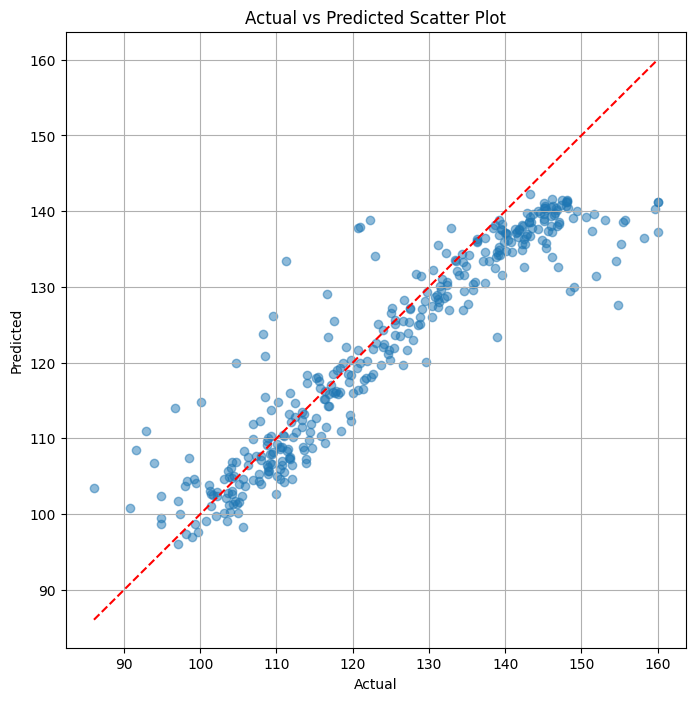

In [16]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test_actual,
    predictions_actual,
    alpha=0.5
)

plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title(
    "Actual vs Predicted Scatter Plot"
)

plt.grid(True)

plt.show()

In [17]:
model.save("gru_model.keras")